In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("data/raw/Media-Matrix-Yarrowia-Narrow-Fixed.csv")
print(df.shape)

(27, 13)


In [4]:
# removing glucose glycerol urea and ammonium sulfate will simply visuals

df= df.drop([0, 1, 2, 3])

In [5]:
#drop pubchem id
df = df.drop(df.columns[2], axis=1)

In [6]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number])

# Replace 0s and apply log10
pseudocount = 1e-10
df_log = np.log10(numeric_cols.replace(0, pseudocount))

In [7]:
df_log.head()

,1_YAR,2a_YAR,2b_YAR,2c_YAR,2d_YAR,3a_YAR,3b_YAR,3c_YAR,4_YAR,5_YAR
4,-10.000000,-2.173551,-2.173551,-2.173551,-2.173551,-0.826764,-10.000000,0.872206,-2.045757,-2.139662
5,-0.283997,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000
6,-2.865101,-3.522879,-3.522879,-3.522879,-3.522879,-10.000000,-10.000000,-2.154902,-3.221849,-2.929962
7,-1.522879,-3.522879,-3.522879,-3.522879,-3.522879,-4.397940,-10.000000,-1.000000,-3.698970,-10.000000
8,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-3.477191,-1.778221,-10.000000,-10.000000,-10.000000


In [8]:
# Add back Compound column before melting
df_log['Compound'] = df['Compound']
df_log['Annotate'] = df['Annotate']

In [9]:
df_log.head()

,1_YAR,2a_YAR,2b_YAR,2c_YAR,2d_YAR,3a_YAR,3b_YAR,3c_YAR,4_YAR,5_YAR,Compound,Annotate
4,-10.000000,-2.173551,-2.173551,-2.173551,-2.173551,-0.826764,-10.000000,0.872206,-2.045757,-2.139662,Calcium chloride dihydrate,Element
5,-0.283997,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,Calcium sulphate dihydrate,Element
6,-2.865101,-3.522879,-3.522879,-3.522879,-3.522879,-10.000000,-10.000000,-2.154902,-3.221849,-2.929962,Cobalt (II) chloride hexahydrate,Element
7,-1.522879,-3.522879,-3.522879,-3.522879,-3.522879,-4.397940,-10.000000,-1.000000,-3.698970,-10.000000,Copper (II) sulphate pentahydrate,Element
8,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-3.477191,-1.778221,-10.000000,-10.000000,-10.000000,Ferric chloride hexahydrate,Element


In [10]:

df_long = pd.melt(
    df_log,
    id_vars=['Compound', 'Annotate'],       # keep these columns as identifiers
    value_vars=[                            # columns to unpivot
        '1_YAR', '2a_YAR', '2b_YAR', '2c_YAR', '2d_YAR',
        '3a_YAR', '3b_YAR', '3c_YAR', '4_YAR', '5_YAR'
    ],
    var_name='Sample',                      # name of the new variable column
    value_name='Log10_Concentration'
)

In [11]:
print(df_long)

                              Compound Annotate Sample  Log10_Concentration
0           Calcium chloride dihydrate  Element  1_YAR           -10.000000
1           Calcium sulphate dihydrate  Element  1_YAR            -0.283997
2     Cobalt (II) chloride hexahydrate  Element  1_YAR            -2.865101
3    Copper (II) sulphate pentahydrate  Element  1_YAR            -1.522879
4          Ferric chloride hexahydrate  Element  1_YAR           -10.000000
..                                 ...      ...    ...                  ...
225                           Inositol  Vitamin  5_YAR            -1.425969
226                     Nicotinic acid  Vitamin  5_YAR            -2.823909
227             para-aminobenzoic acid  Vitamin  5_YAR            -4.522879
228                         Pyridoxine  Vitamin  5_YAR            -2.739150
229                           Thiamine  Vitamin  5_YAR            -2.774185

[230 rows x 4 columns]


In [12]:
filtered_df_long = df_long.replace(-10, np.nan)

In [13]:
# Get the original Compound order
compound_order = df['Compound'].tolist()

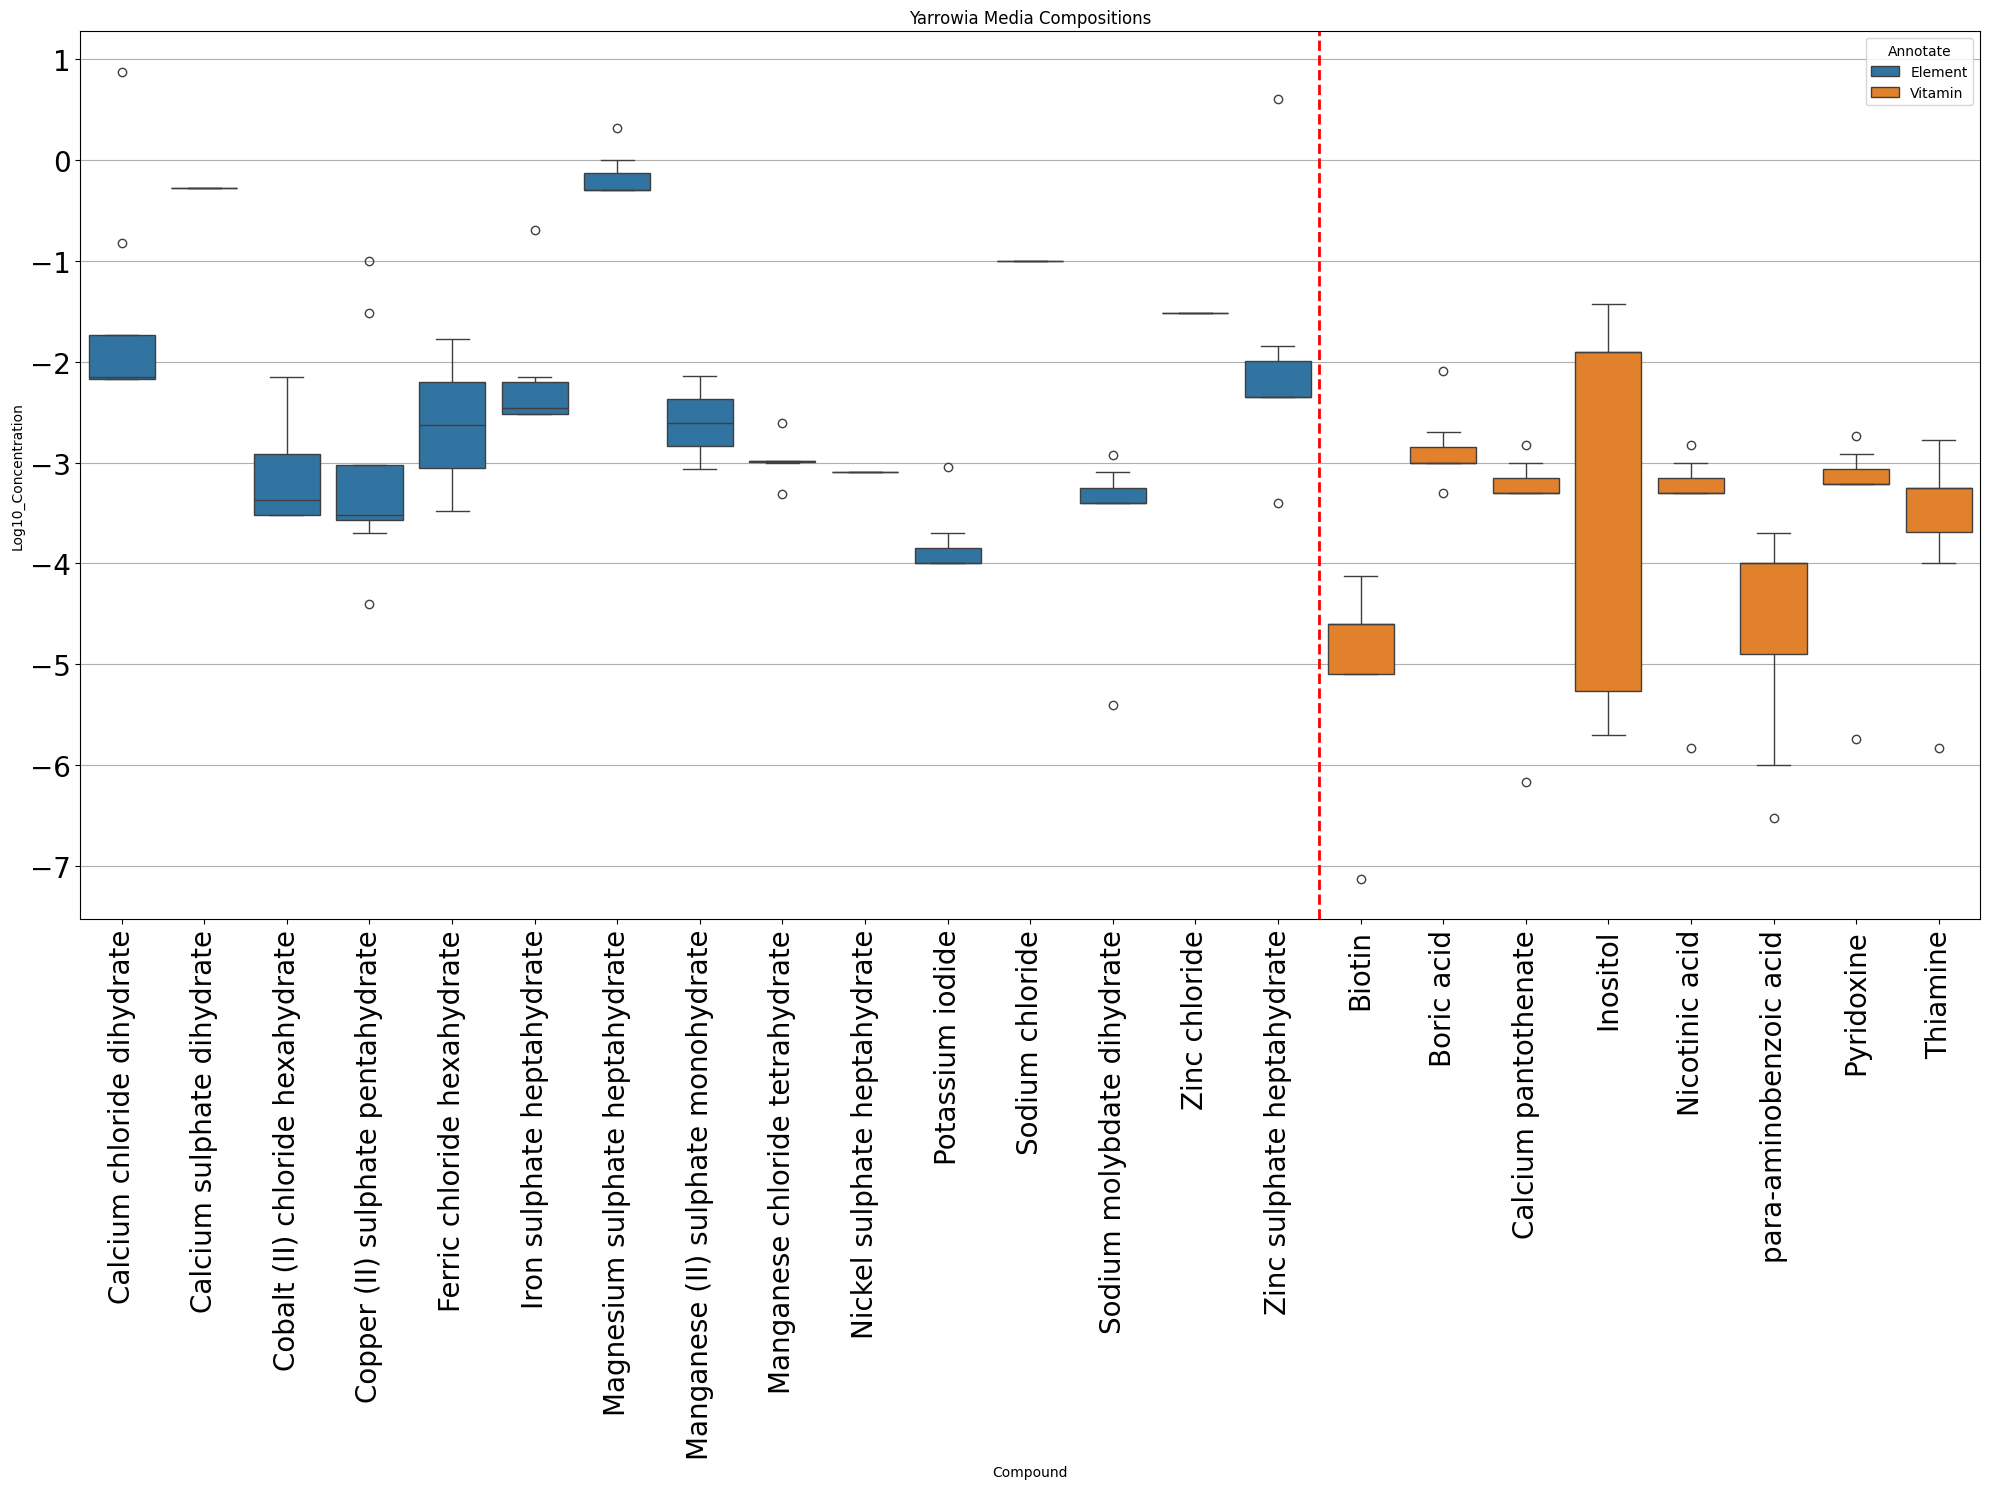

In [18]:
plt.figure(figsize=(20, 15))
sns.boxplot(data=df_long[df_long['Log10_Concentration'] > -10],  # exclude pseudocount
            x='Compound', y='Log10_Concentration', hue='Annotate', order=compound_order)
plt.xticks(size = 20, rotation=90)
plt.yticks(size = 20)
plt.title('Yarrowia Media Compositions')
plt.grid(axis='y')
plt.axvline(x=14.5, color='r', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()